# 과제 1: 당뇨병 데이터로 Feature Selection, 이상치 탐지 진행해보기

In [189]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import PolynomialFeatures

from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Lasso, Ridge
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
from scipy import stats
from sklearn.neighbors import LocalOutlierFactor

In [190]:
df = pd.read_csv('train.csv')

In [191]:
print(df.columns)

Index(['ID', 'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
       'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [192]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI','DiabetesPedigreeFunction','Age']
df[cols] = df[cols].replace(0, np.nan) 

In [193]:
df = df.dropna()

In [194]:
df.isnull().sum()

ID                          0
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [195]:
X = df.drop(columns=['Outcome', 'ID'])
y = df['Outcome']

# Filter 

## 1. F-statistic (ANOVA)

In [196]:
selector_f = SelectKBest(score_func=f_classif, k=2)
X_f = selector_f.fit_transform(X, y)
X_f.shape

(332, 2)

In [197]:
print(f"F-statistic(ANOVA) scores: {selector_f.scores_}")
# 그룹간 평균 차이 검정 /  F값이 클수록 Feature가 Target구분에 유용

F-statistic(ANOVA) scores: [ 20.98512438 106.91028705  12.01347221  22.64191962  36.71198602
  22.45022229  15.40296333  41.08245256]


## 2. Mutual Information

In [198]:
selector_mi = SelectKBest(score_func=mutual_info_classif, k=2)
X_mi = selector_mi.fit_transform(X, y)

print(f"MI scores:{selector_mi.scores_}")
# MI값이 클수록 Feature가 유용함

MI scores:[0.04191805 0.14507677 0.         0.02423775 0.07178077 0.01305324
 0.         0.09039368]


## 3. Variance Threshold

In [199]:
selector_var = VarianceThreshold(threshold=0.2)
X_var = selector_var.fit_transform(X)

print(f"Variance:{selector_var.variances_}")
# 분산이 임계값보다 낮으면(정보가 없다고 판단) -> 제거

Variance:[1.00749292e+01 9.36887021e+02 1.54627050e+02 1.04661743e+02
 1.48860271e+04 4.40405708e+01 1.18517250e-01 1.06563607e+02]


# Wrapper

## RFE로 피처 선택

In [200]:
model = LogisticRegression(max_iter=10000)
rfe = RFE(estimator=model, n_features_to_select=7)
X_rfe = rfe.fit_transform(X, y)
selected_features = [X.columns[i] for i in range(len(rfe.support_)) if rfe.support_[i]]

In [201]:
print("전체 피처 수:", X.shape[1])
print("선택된 피처 수:", X_rfe.shape[1])
print("피처 순위:", rfe.ranking_)
print("선택된 피처:", selected_features )

전체 피처 수: 8
선택된 피처 수: 7
피처 순위: [1 1 1 1 2 1 1 1]
선택된 피처: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [202]:
score_all = cross_val_score(model, X, y, cv=5).mean()
score_rfe = cross_val_score(model, X_rfe, y, cv=5).mean()
print(f"전체 피처 정확도: {score_all:.3f}")
print(f"선택된 피처 정확도: {score_rfe:.3f}")

전체 피처 정확도: 0.759
선택된 피처 정확도: 0.765


# Embedded 

## 1. Lasso

In [203]:
lasso = Lasso(alpha=0.01)
lasso.fit(X, y)
lasso_coef = np.abs(lasso.coef_)
print("Lasso - 0인 계수:", np.sum(lasso_coef == 0))

Lasso - 0인 계수: 0


In [204]:
rf = DecisionTreeClassifier(max_depth=5, random_state=42)
rf.fit(X, y)
importances = rf.feature_importances_
#불필요한 Feature의 가중치를 0으로 만듦

In [205]:
importances

array([0.03123204, 0.47799864, 0.00844109, 0.02000504, 0.09238624,
       0.05916486, 0.1277747 , 0.1829974 ])

In [206]:
indices = np.argsort(importances)[::-1][:8]
print("Top 8 중요 피처")
for i in indices:
    print(f"{cancer.feature_names[i]}: {importances[i]:.4f}")

Top 8 중요 피처
mean texture: 0.4780
mean concave points: 0.1830
mean concavity: 0.1278
mean smoothness: 0.0924
mean compactness: 0.0592
mean radius: 0.0312
mean area: 0.0200
mean perimeter: 0.0084


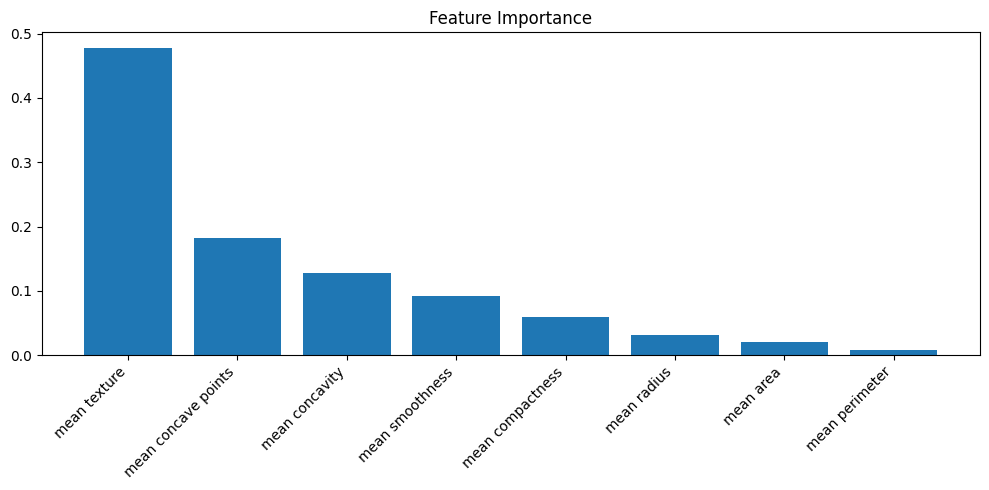

In [207]:
# 시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.bar(range(8), importances[indices])
plt.xticks(range(8), [cancer.feature_names[i] for i in indices],rotation=45, ha='right')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

# 이상치 탐지 

## 1. Z-score 

In [208]:
np.random.seed(42)
data = np.random.normal(100, 15, 100)  

data = np.append(data, [200, 10, 250])  # 이상치 추가

# Z-Score 계산
z_scores = np.abs(stats.zscore(data))
threshold = 3

# 이상치 탐지 : 평균에서 얼마만큼 표준편차가 떨어져있냐
outliers = np.where(z_scores > threshold)
print("이상치 인덱스:", outliers[0])
print("이상치 값:", data[outliers])
print("이상치 Z-Score:", z_scores[outliers])

이상치 인덱스: [100 101 102]
이상치 값: [200.  10. 250.]
이상치 Z-Score: [4.16895504 3.75531405 6.25428901]


## 2. IQR 

In [209]:
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1

# 이상치 경계
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 이상치 탐지
outliers_mask = (data < lower_bound) | (data > upper_bound)
outliers = data[outliers_mask]

print(f"Q1(하위 25%): {Q1:.2f}")
print(f"Q3(하위 75%): {Q3:.2f}")
print(f"IQR(Q3 - Q1): {IQR:.2f}")
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")
print(f"이상치: {outliers}")

Q1(하위 25%): 90.98
Q3(하위 75%): 107.57
IQR(Q3 - Q1): 16.59
Lower bound: 66.09
Upper bound: 132.46
이상치: [ 60.70382344 200.          10.         250.        ]


/var/folders/7d/4294lrxx67jdcn0_3qst6jf00000gn/T/ipykernel_36633/3359473825.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


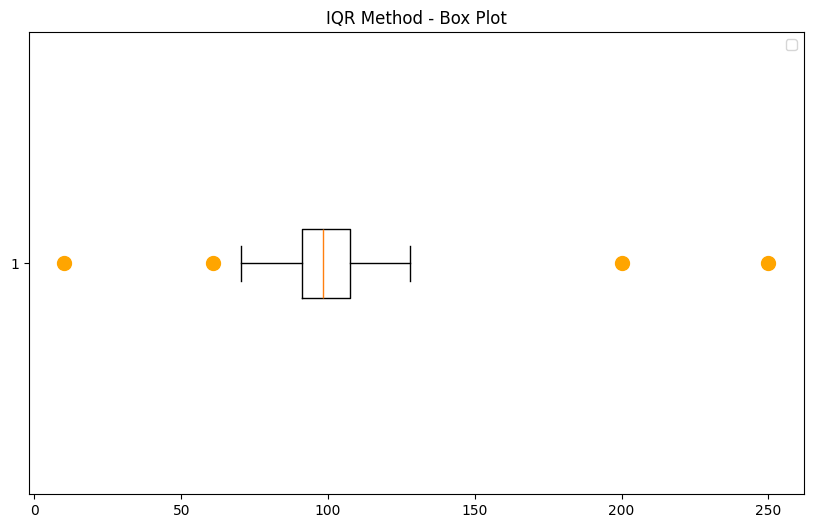

In [210]:
# Box plot
plt.figure(figsize=(10, 6))
plt.boxplot(data, vert=False)
plt.scatter(outliers, [1]*len(outliers), c='orange', s=100, zorder=3)
plt.title('IQR Method - Box Plot')
plt.legend()
plt.show()

## 3. DBSCAN 

In [211]:
# 데이터 생성 (정상 + 이상치)
X, _ = make_blobs(n_samples=300, centers=3, random_state=42)
X = np.vstack([X, [[10, 10], [-10, -10], [10, -10]]])  # 이상치 추가

# DBSCAN 적용
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X)

# 이상치 추출
outliers = X[labels == -1]
inliers = X[labels != -1]

# 군집화 중심
print(f"정상 데이터: {len(inliers)}개")
print(f"이상치: {len(outliers)}개")
print(f"군집 개수: {len(set(labels)) - (1 if -1 in labels else 0)}개")

정상 데이터: 248개
이상치: 55개
군집 개수: 5개


/var/folders/7d/4294lrxx67jdcn0_3qst6jf00000gn/T/ipykernel_36633/964837005.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


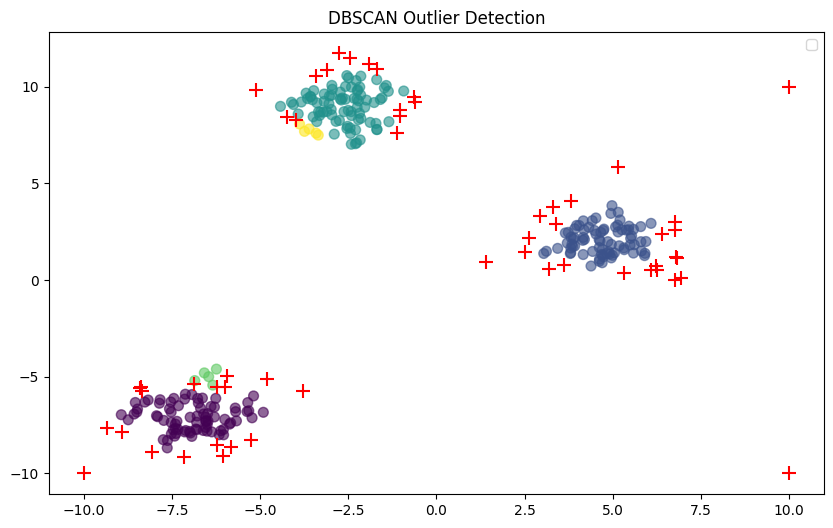

In [212]:
# 시각화
plt.figure(figsize=(10, 6))
plt.scatter(inliers[:, 0], inliers[:, 1], c=labels[labels != -1],cmap='viridis', alpha=0.6, s=50)
plt.scatter(outliers[:, 0], outliers[:, 1], c='red',s=100, marker='+')
plt.title('DBSCAN Outlier Detection')
plt.legend()
plt.show()

## 4. LOF 

In [213]:
# 데이터 생성 (다양한 밀도의 군집)
np.random.seed(42)
X1 = np.random.normal(0, 0.5, (100, 2))  # 조밀한 군집
X2 = np.random.normal(5, 1.5, (50, 2))   # 느슨한 군집
X_outliers = np.array([[7, 7], [-3, -3], [0, 5]])  # 이상치
X = np.vstack([X1, X2, X_outliers])

# LOF 적용
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
labels = lof.fit_predict(X)
scores = lof.negative_outlier_factor_

# 이상치 추출
outliers = X[labels == -1]
inliers = X[labels == 1]

#이상치 탐지 중심
print(f"정상 데이터: {len(inliers)}개")
print(f"이상치: {len(outliers)}개")
print(f"이상치 LOF scores: {scores[labels == -1]}")

정상 데이터: 145개
이상치: 8개
이상치 LOF scores: [-1.93321727 -1.69263105 -2.32018317 -1.5555237  -4.29849615 -1.54581308
 -6.93339949 -3.13299896]


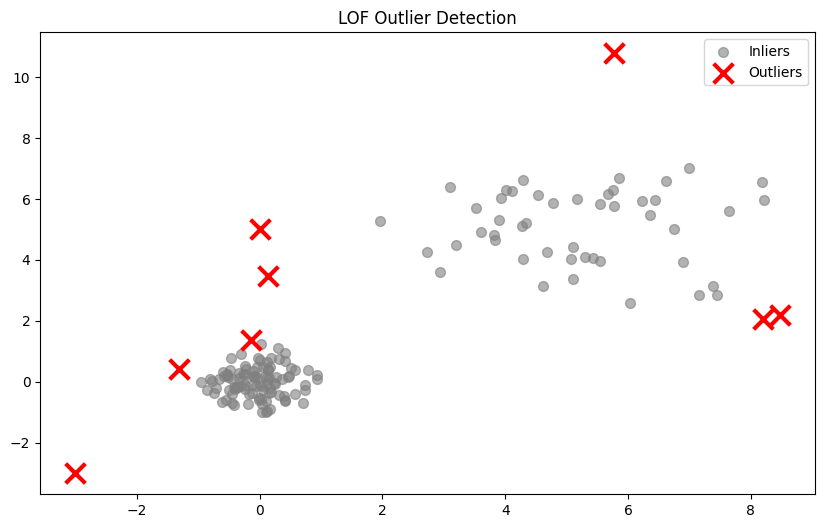

In [214]:
# 시각화
plt.figure(figsize=(10, 6))
plt.scatter(inliers[:, 0], inliers[:, 1], c='gray',alpha=0.6, s=50, label='Inliers')
plt.scatter(outliers[:, 0], outliers[:, 1], c='red',s=200, marker='x', label='Outliers', linewidths=3)
plt.title('LOF Outlier Detection')
plt.legend()
plt.show()